In [ ]:
!pip install git+https://github.com/neZorinEgor/magnesis.git@dba7d20c42aa8b2ea2b75b4ae73104ecdaf41381
!wget https://huggingface.co/neZorinEgor/magnesis/resolve/main/weights.zip -O weights.zip
!unzip weights.zip
!rm weights.zip

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchview import draw_graph

from magnesis import GeomagneticNet, make_dataset

from warnings import filterwarnings
filterwarnings("ignore")

In [7]:
model = GeomagneticNet(model_dir="/home/zorinep/workdir/magnesis/notebooks/examples/weights2", device="cuda")

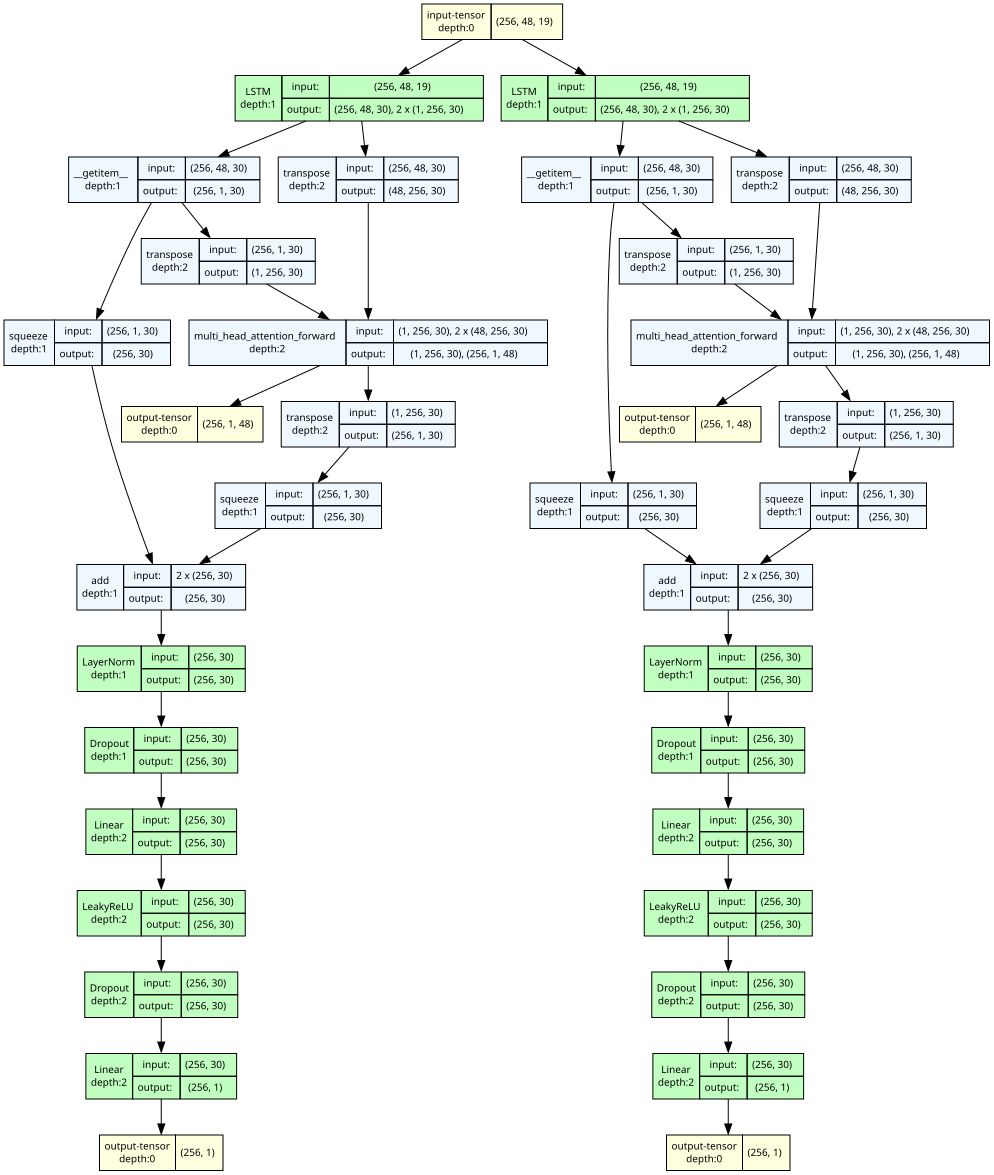

In [8]:
batch_size = 256
X_window_size = 48
n_features = 19
input_size = [batch_size, X_window_size, n_features]
draw_graph(model=model._model, input_size=[256, 48, 19]).visual_graph

In [1]:
# !mkdir -p data/omni
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2019.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2020.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2021.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2022.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2023.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2024.dat
# !wget -P data/omni https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2025.dat

--2026-06-23 02:59:31--  https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2019.dat
Resolving spdf.gsfc.nasa.gov (spdf.gsfc.nasa.gov)... 169.154.154.63, 2001:4d0:2418:121::63
Connecting to spdf.gsfc.nasa.gov (spdf.gsfc.nasa.gov)|169.154.154.63|:443... 

connected.
HTTP request sent, awaiting response... 200 OK
Length: 2873280 (2.7M)
Saving to: ‘data/omni/omni2_2019.dat’

omni2_2019.dat      100%[===================>]   2.74M   339KB/s    in 14s     

2026-06-23 02:59:46 (199 KB/s) - ‘data/omni/omni2_2019.dat’ saved [2873280/2873280]

--2026-06-23 02:59:46--  https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2020.dat
Resolving spdf.gsfc.nasa.gov (spdf.gsfc.nasa.gov)... 169.154.154.63, 2001:4d0:2418:121::63
Connecting to spdf.gsfc.nasa.gov (spdf.gsfc.nasa.gov)|169.154.154.63|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2881152 (2.7M)
Saving to: ‘data/omni/omni2_2020.dat’

omni2_2020.dat      100%[===================>]   2.75M  59.7KB/s    in 16s     

2026-06-23 03:00:04 (174 KB/s) - ‘data/omni/omni2_2020.dat’ saved [2881152/2881152]

--2026-06-23 03:00:04--  https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2_2021.dat
Resolving spdf.gsfc.nasa.gov (spdf.gsfc.nasa.gov)... 169.154.154.63, 200

In [9]:
dataset_2019_2025 = make_dataset(omni2_dir="./data/omni")
dataset_2019_2025.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,...,V_Long_GSE,V_Lat_GSE,Dst,AE,hour_sin,hour_cos,day_sin,day_cos,week_sin,week_cos
0,2019-01-01 00:00:00,1.7,3.3,-2.4,10,69.5,-3,25,61944.0,3.9,...,0.2,-1.9,-8,28,0.000000,1.000000,0.017202,0.999852,0.781831,0.62349
1,2019-01-01 01:00:00,-1.0,3.9,0.5,10,69.5,-12,24,59925.0,3.9,...,-0.1,-1.0,-11,36,0.258819,0.965926,0.017202,0.999852,0.781831,0.62349
2,2019-01-01 02:00:00,1.9,3.4,2.7,10,69.5,-24,14,49175.0,4.0,...,0.6,-2.0,-9,38,0.500000,0.866025,0.017202,0.999852,0.781831,0.62349
3,2019-01-01 03:00:00,2.5,4.1,2.8,13,69.5,-4,21,36301.0,4.5,...,0.0,-1.9,-7,25,0.707107,0.707107,0.017202,0.999852,0.781831,0.62349
4,2019-01-01 04:00:00,-0.1,4.6,1.1,13,69.5,-6,34,55764.0,5.2,...,0.2,-1.3,-4,40,0.866025,0.500000,0.017202,0.999852,0.781831,0.62349


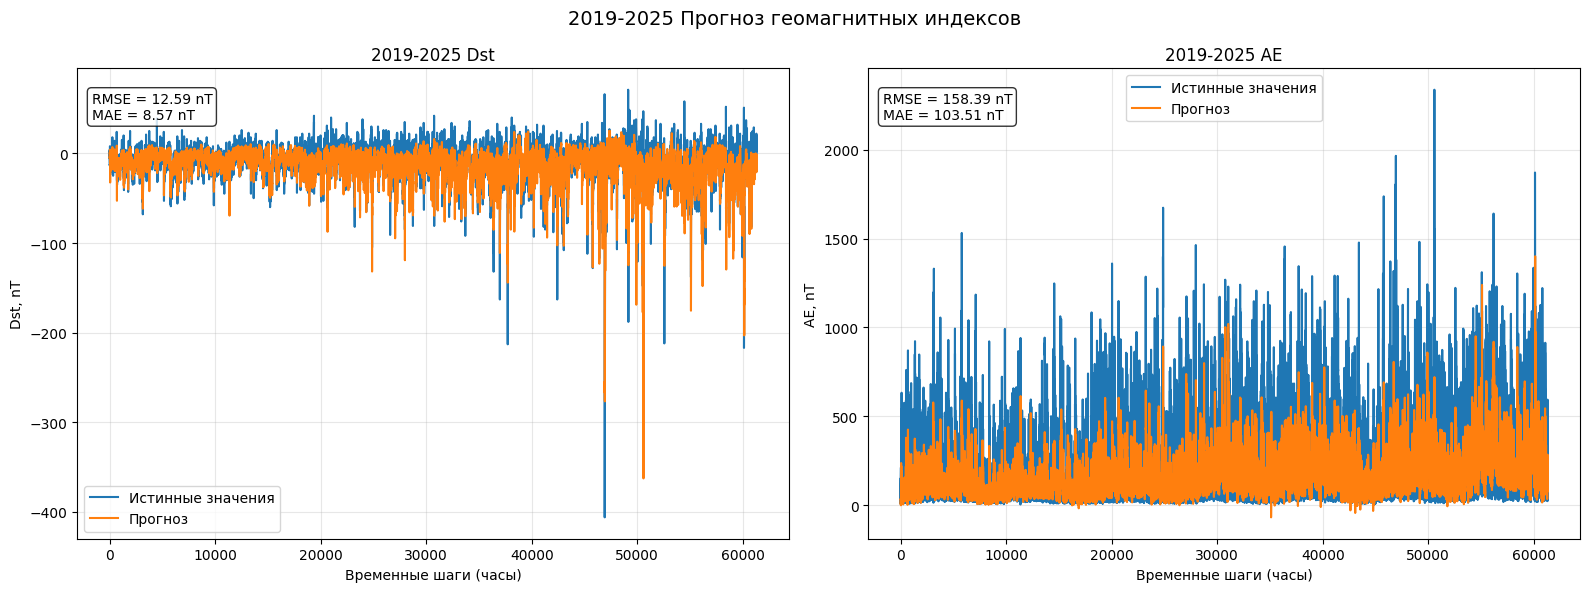

2019-2025 Результаты прогноза
Dst: RMSE = 12.59 nT, MAE = 8.57 nT
AE:  RMSE = 158.39 nT, MAE = 103.51 nT


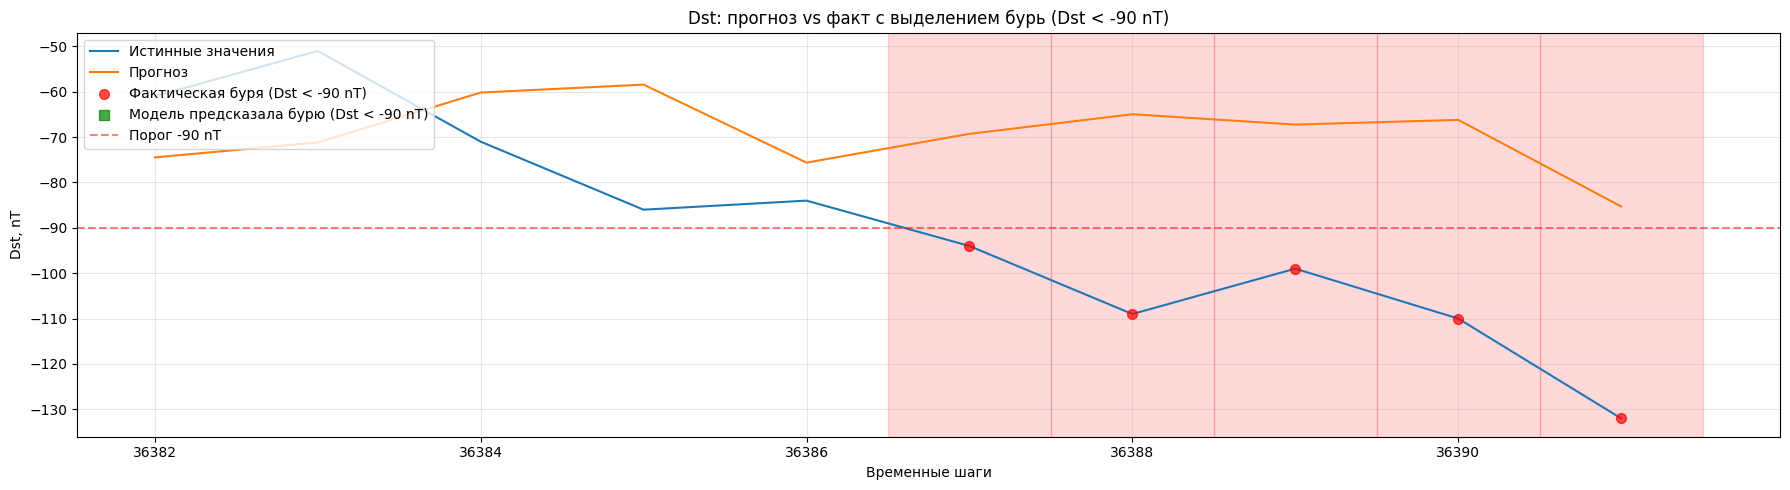

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


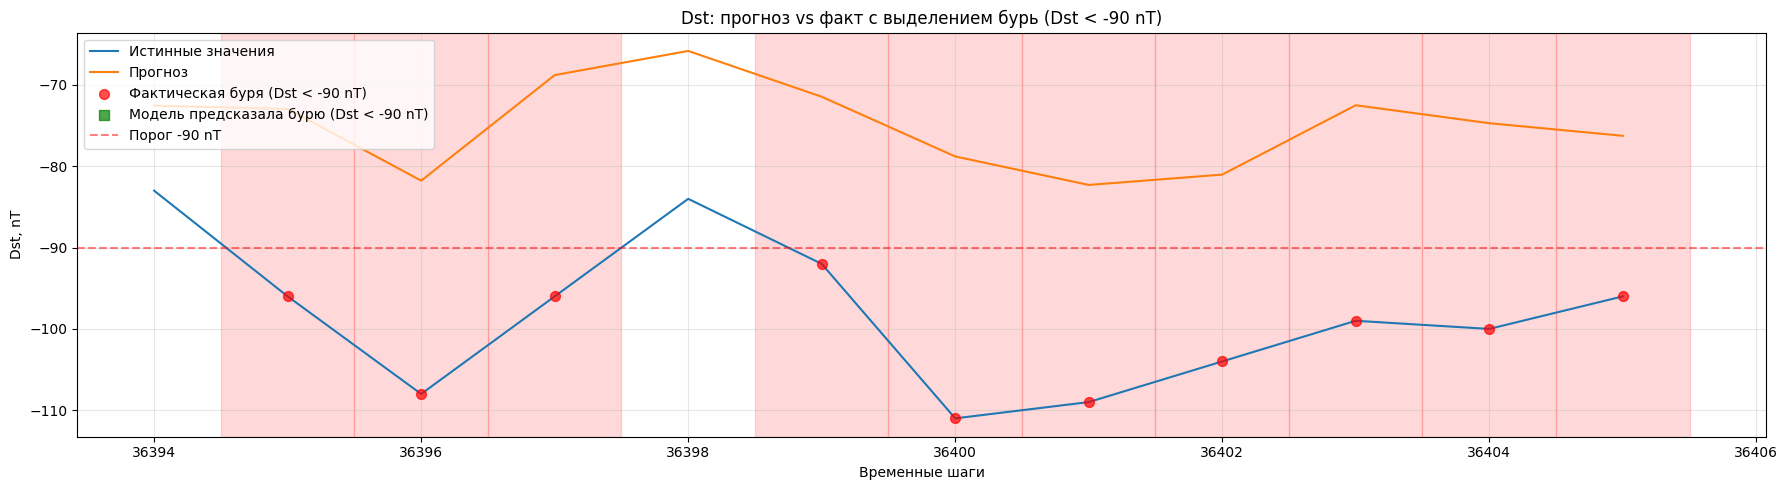

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


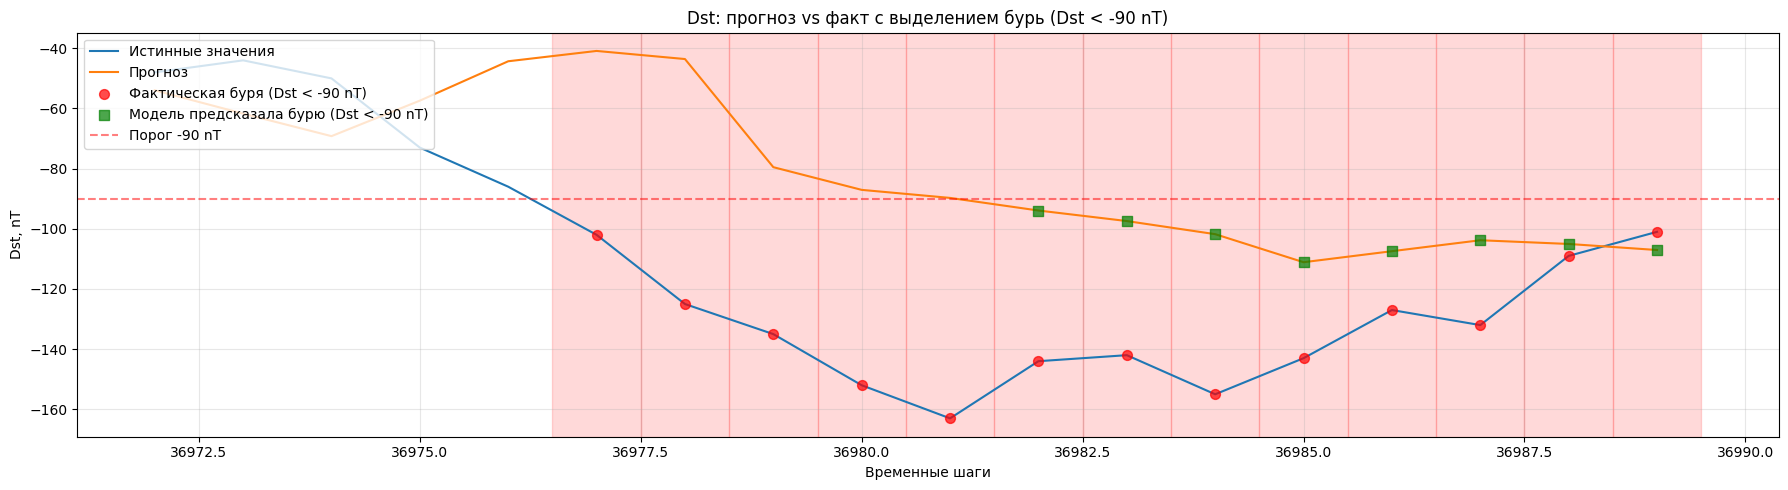

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 8
Precision: 1.000
Recall: 0.615
F1: 0.762


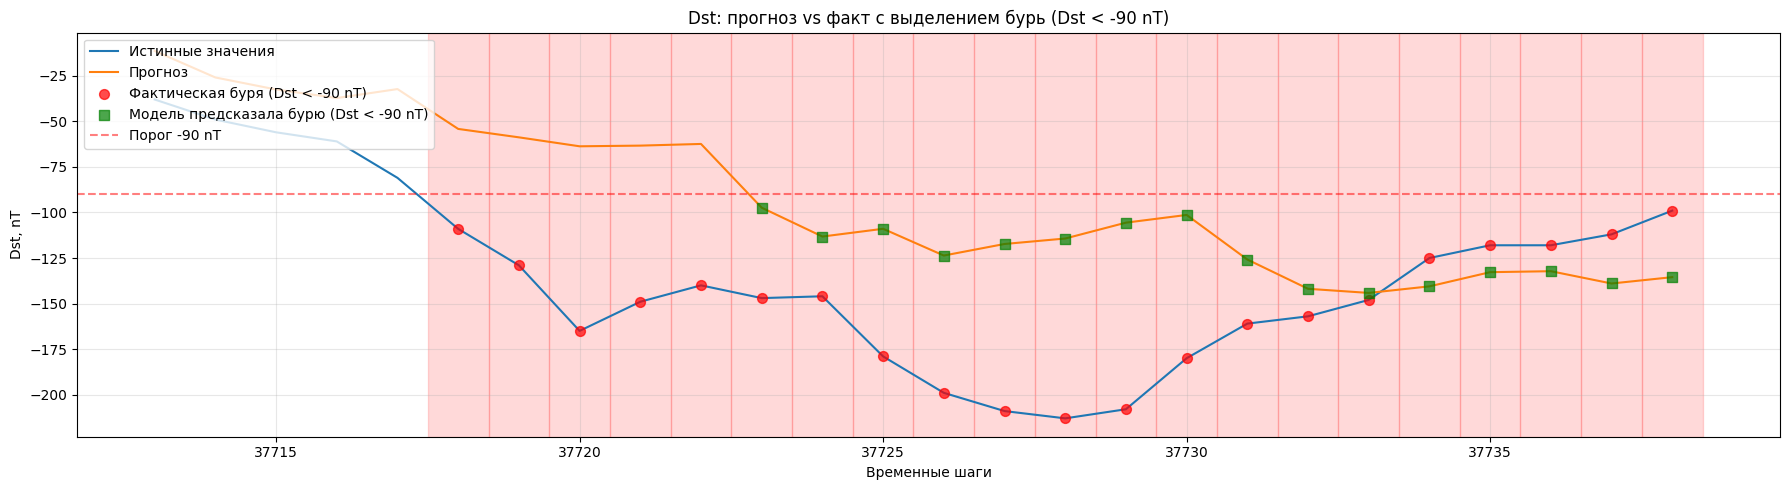

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 16
Precision: 1.000
Recall: 0.762
F1: 0.865


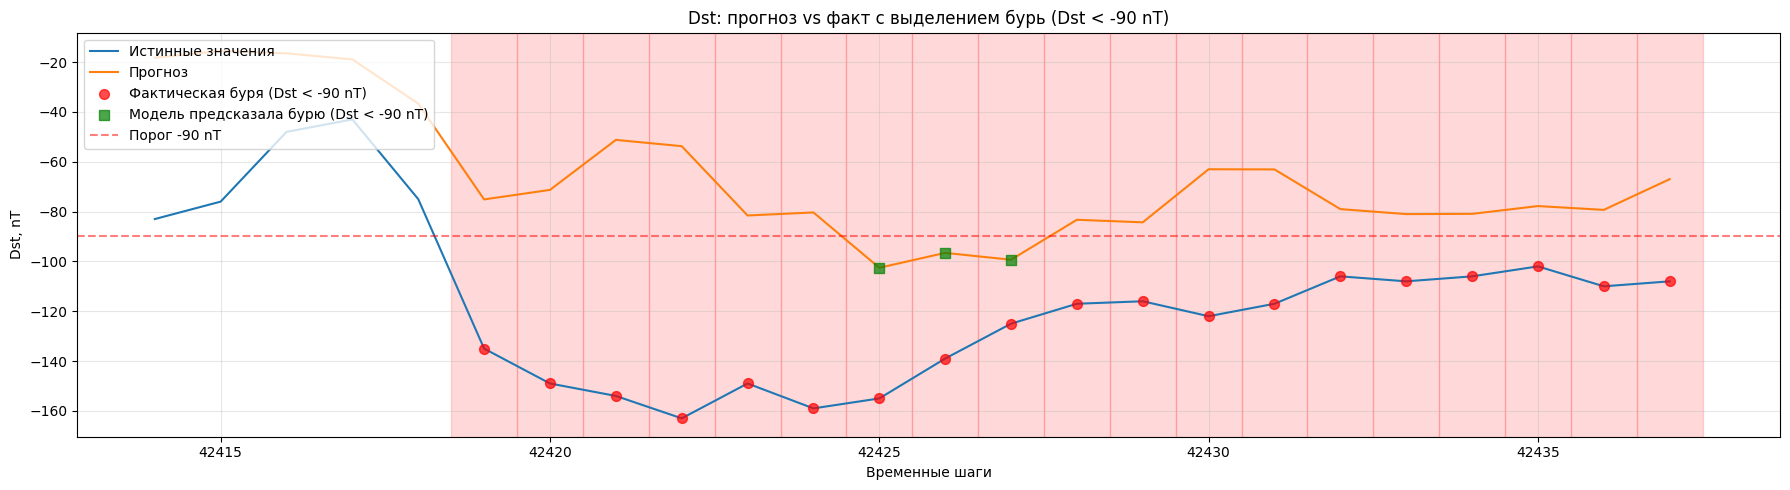

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 3
Precision: 1.000
Recall: 0.158
F1: 0.273


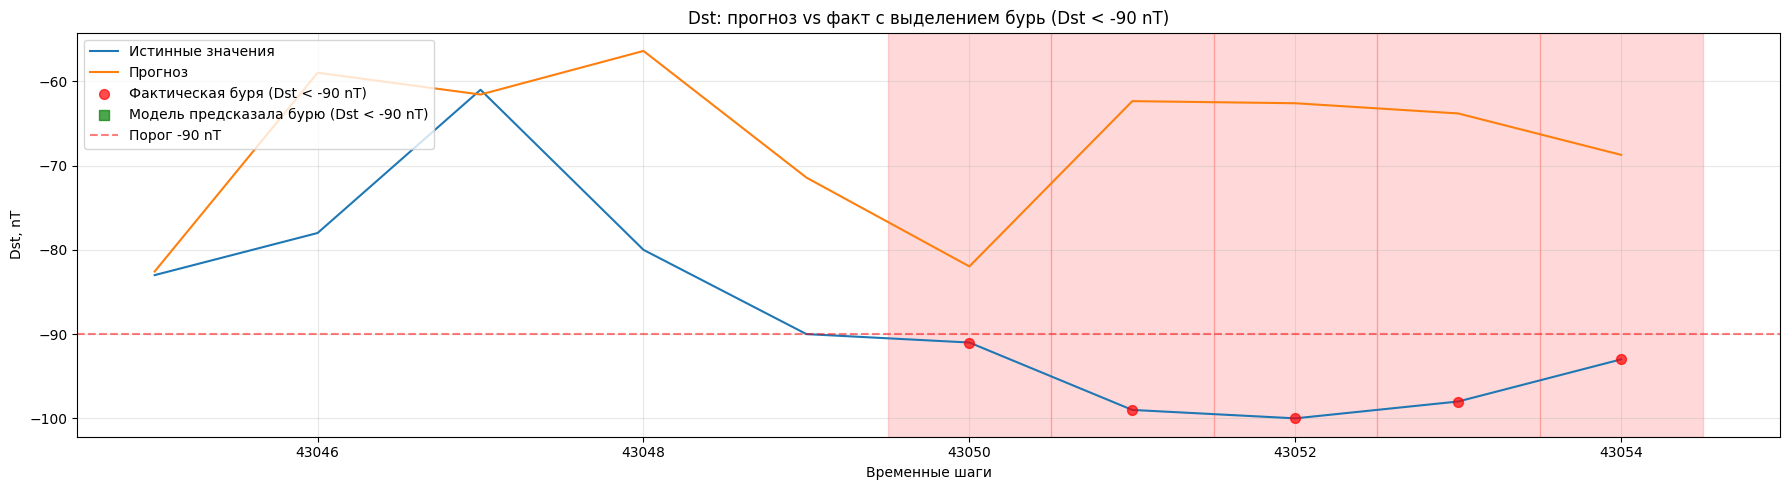

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


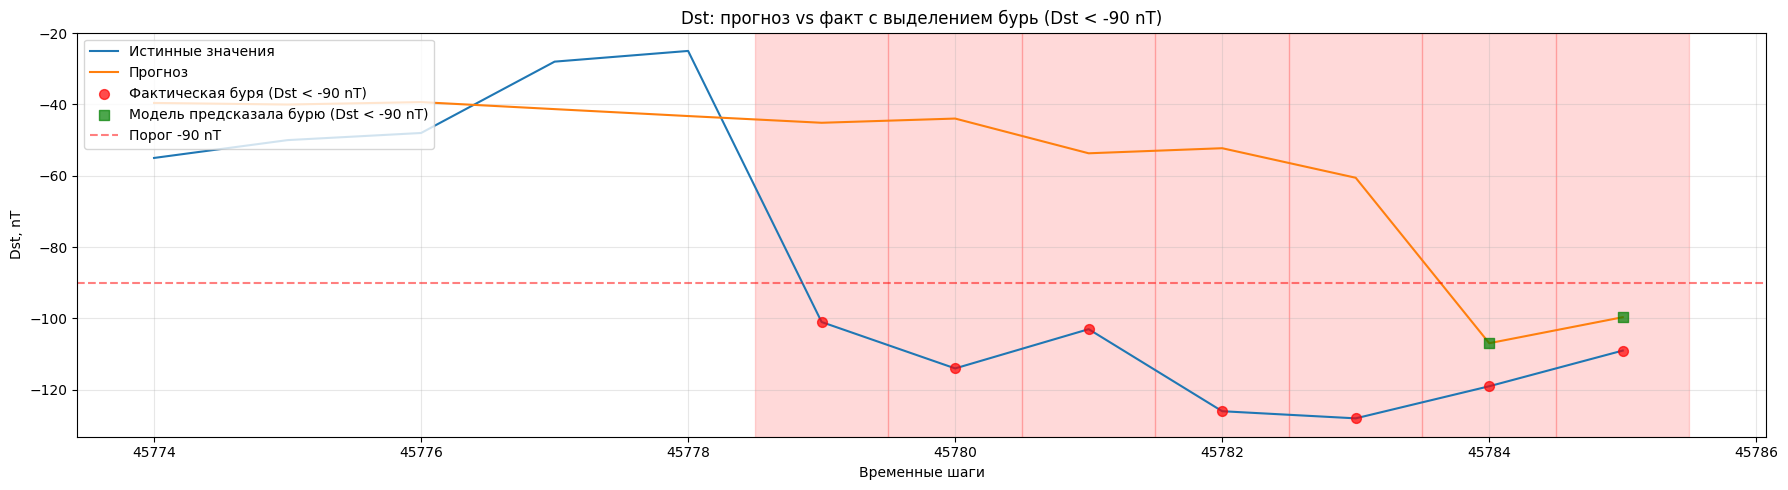

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.286
F1: 0.444


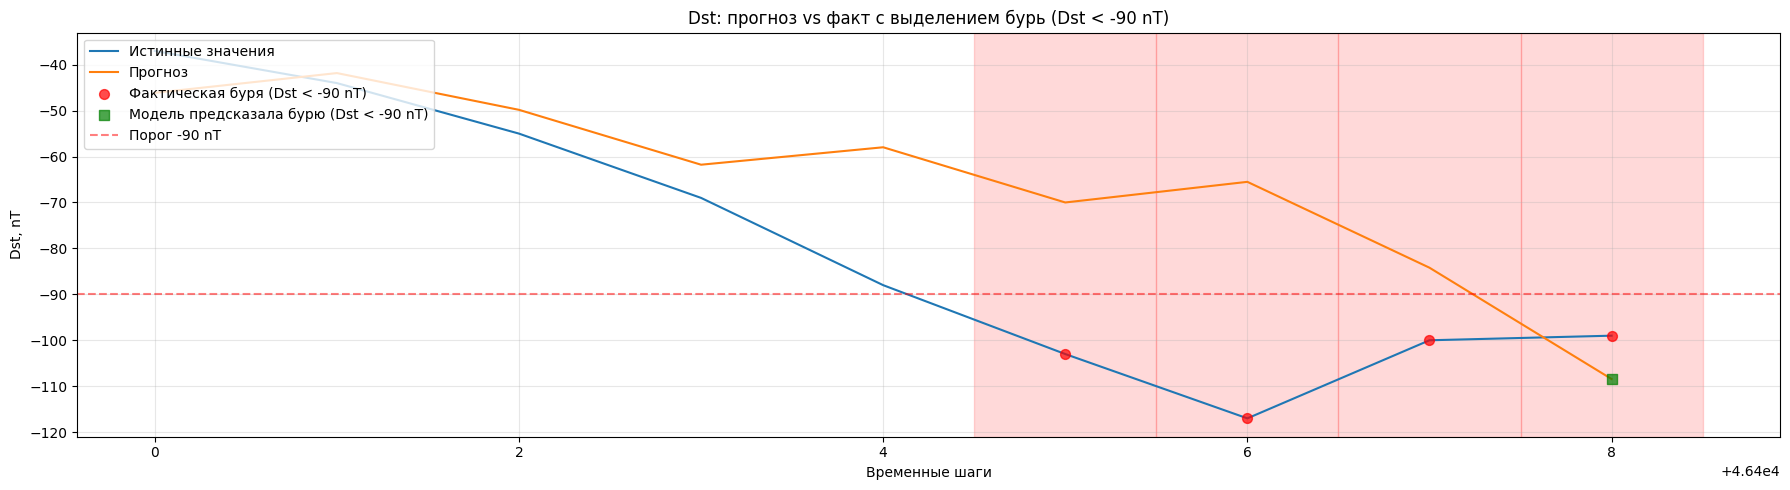

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 4
Всего моментов, когда модель предсказала бурю: 1
Precision: 1.000
Recall: 0.250
F1: 0.400


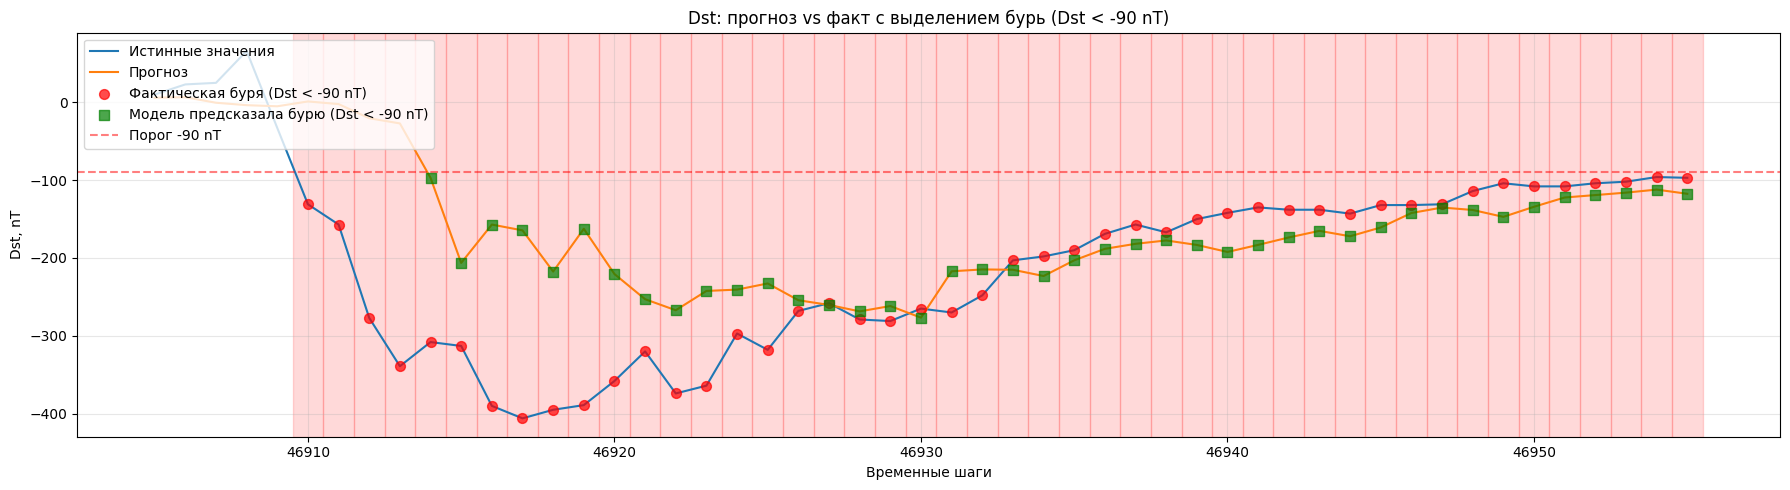

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 46
Всего моментов, когда модель предсказала бурю: 42
Precision: 1.000
Recall: 0.913
F1: 0.955


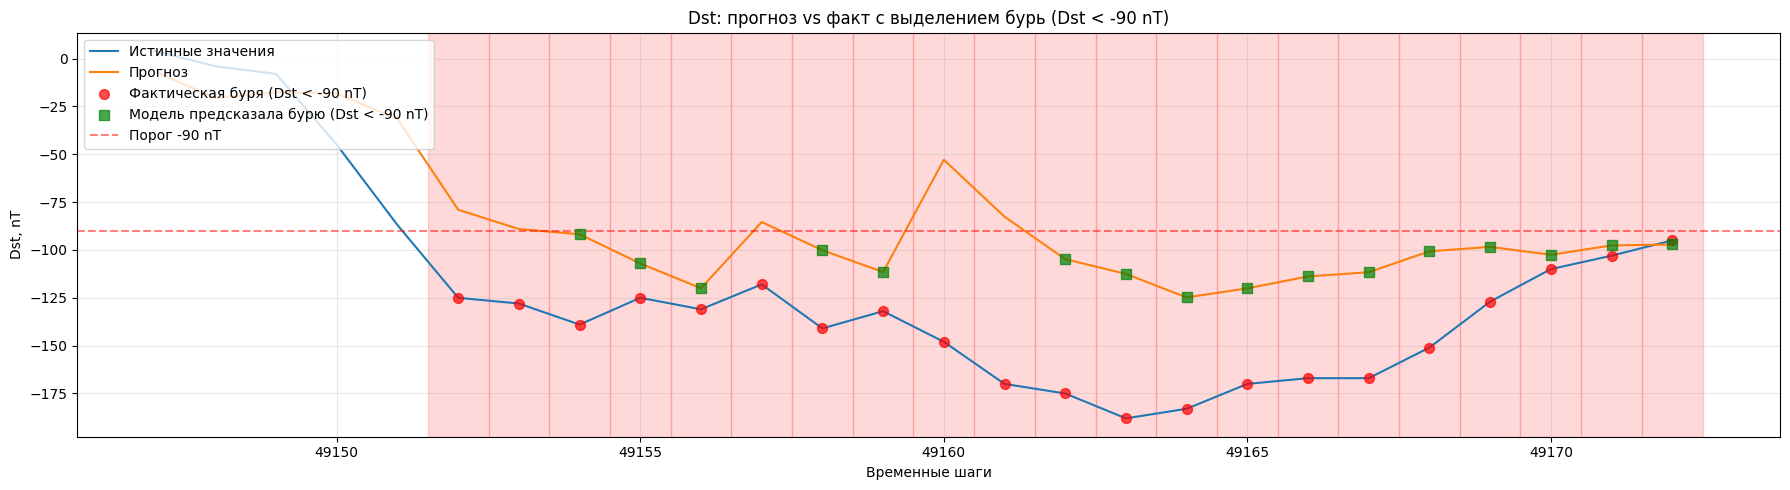

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 21
Всего моментов, когда модель предсказала бурю: 16
Precision: 1.000
Recall: 0.762
F1: 0.865


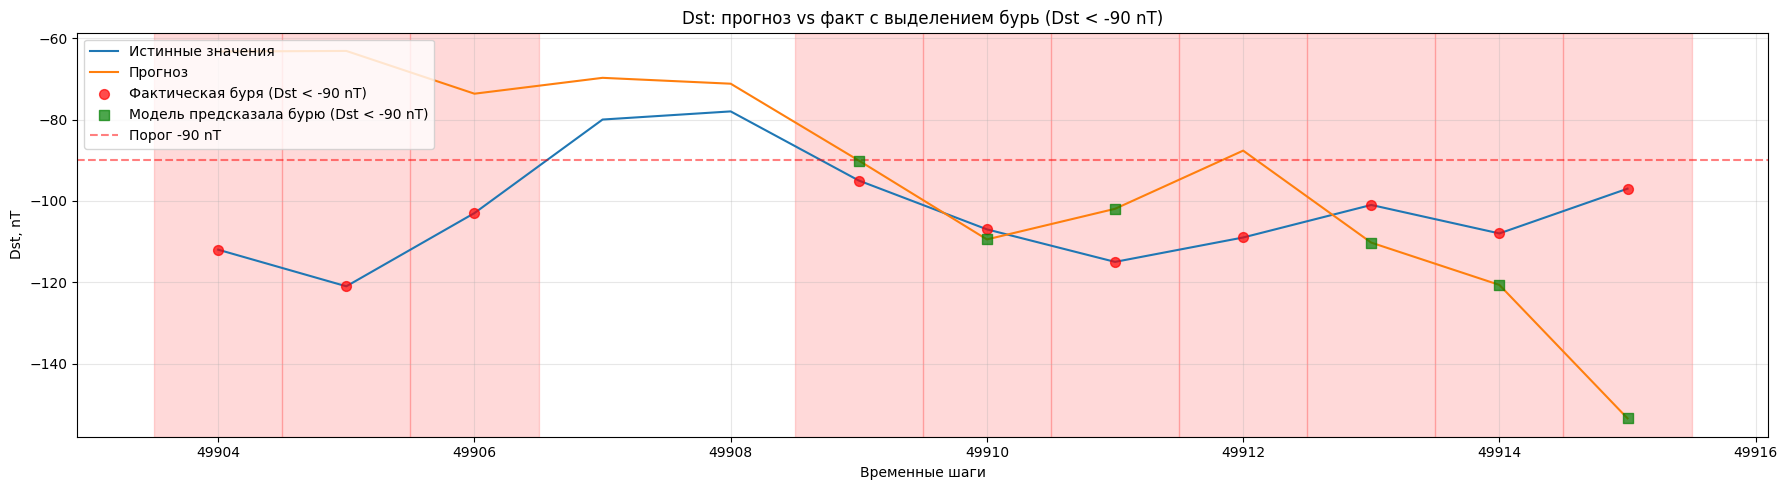

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 10
Всего моментов, когда модель предсказала бурю: 6
Precision: 1.000
Recall: 0.600
F1: 0.750


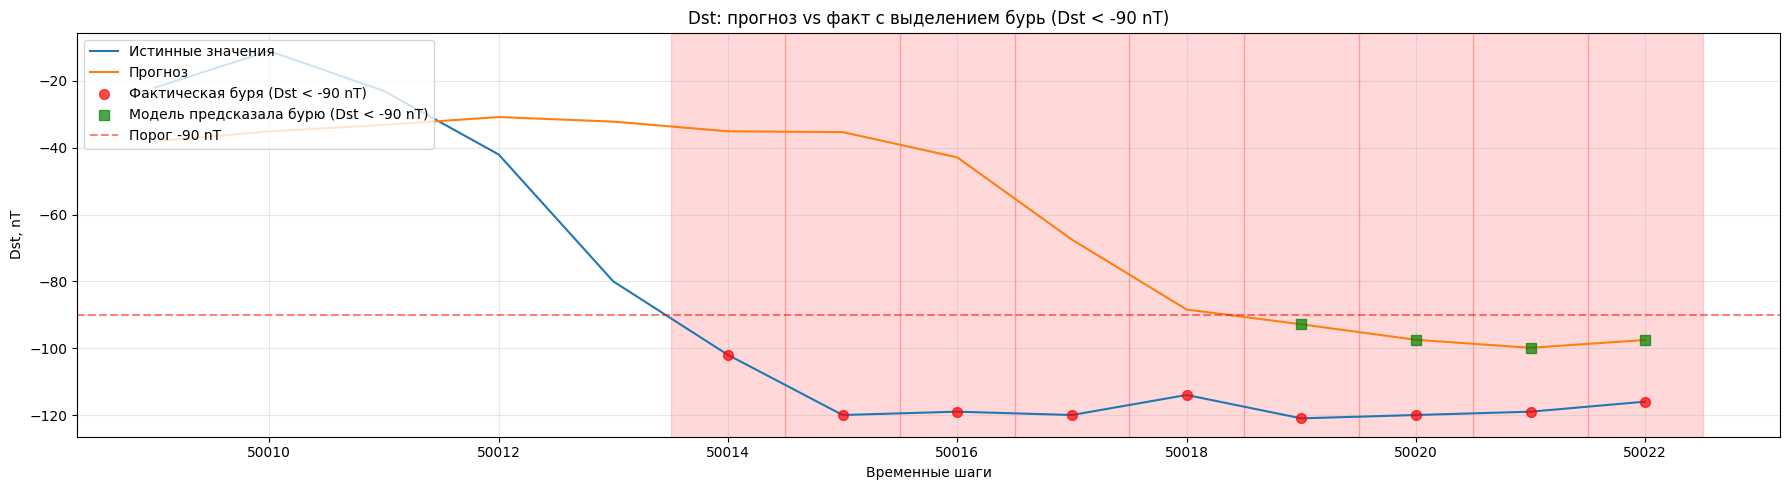

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 4
Precision: 1.000
Recall: 0.444
F1: 0.615


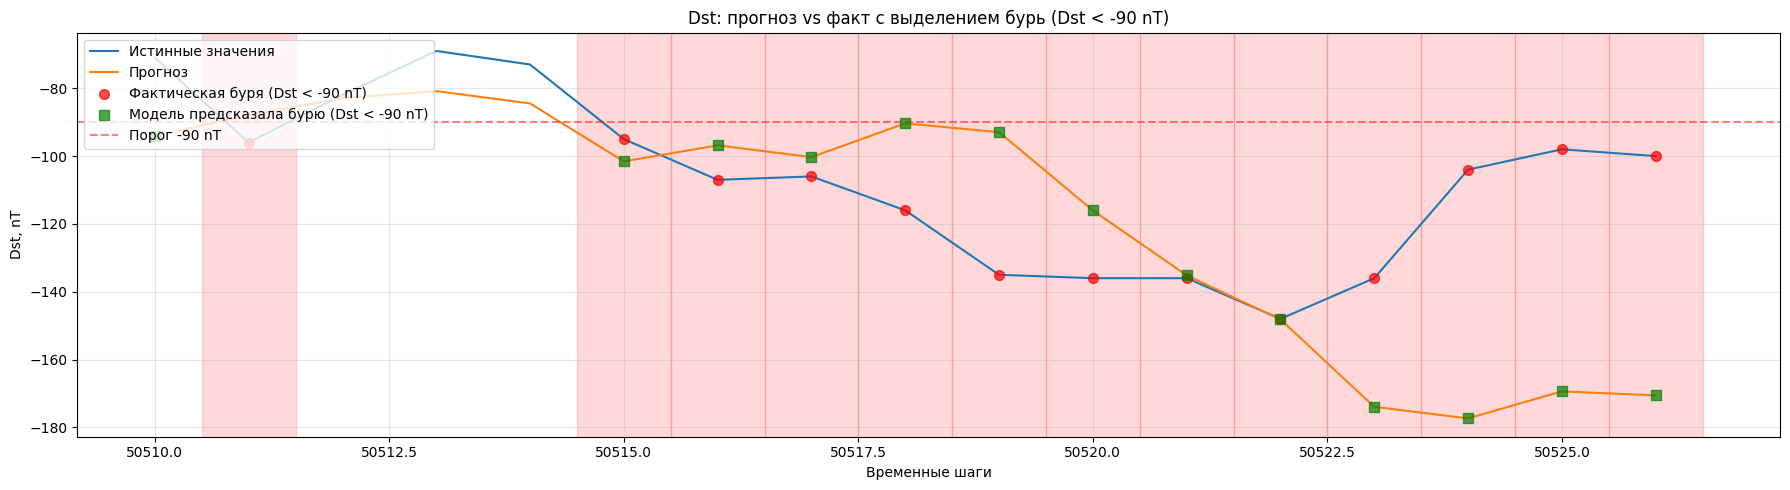

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 13
Всего моментов, когда модель предсказала бурю: 13
Precision: 0.923
Recall: 0.923
F1: 0.923


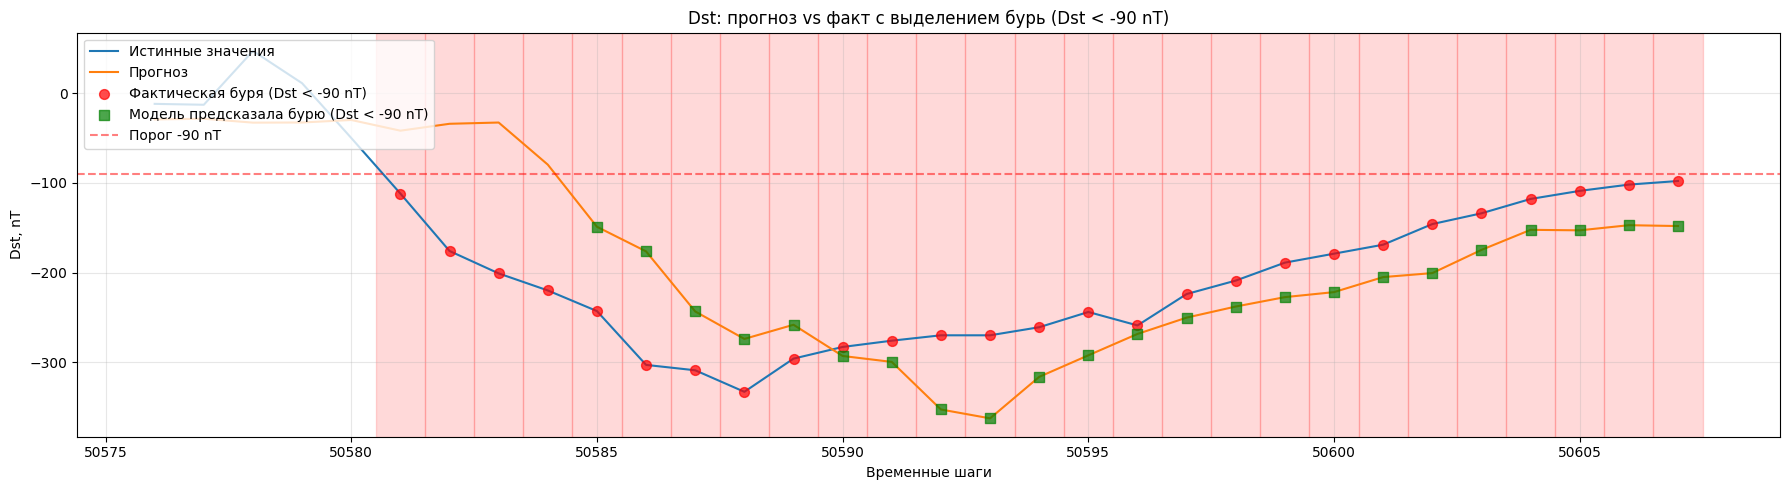

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 27
Всего моментов, когда модель предсказала бурю: 23
Precision: 1.000
Recall: 0.852
F1: 0.920


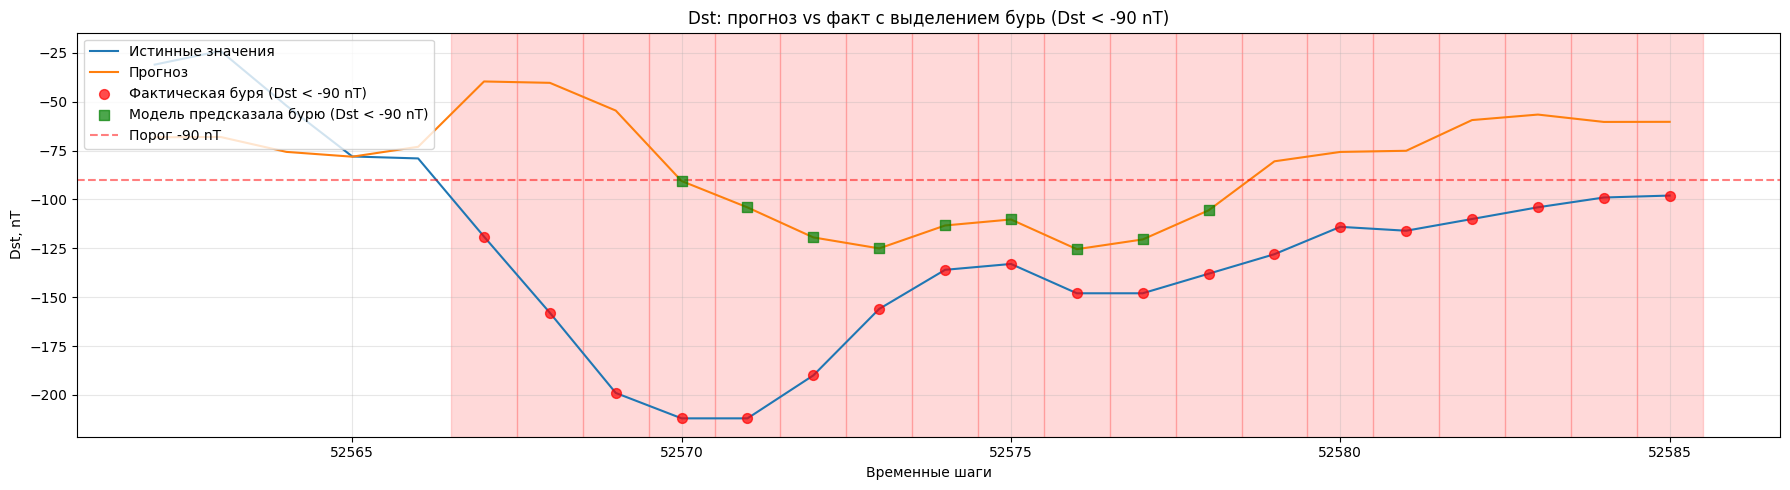

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 19
Всего моментов, когда модель предсказала бурю: 9
Precision: 1.000
Recall: 0.474
F1: 0.643


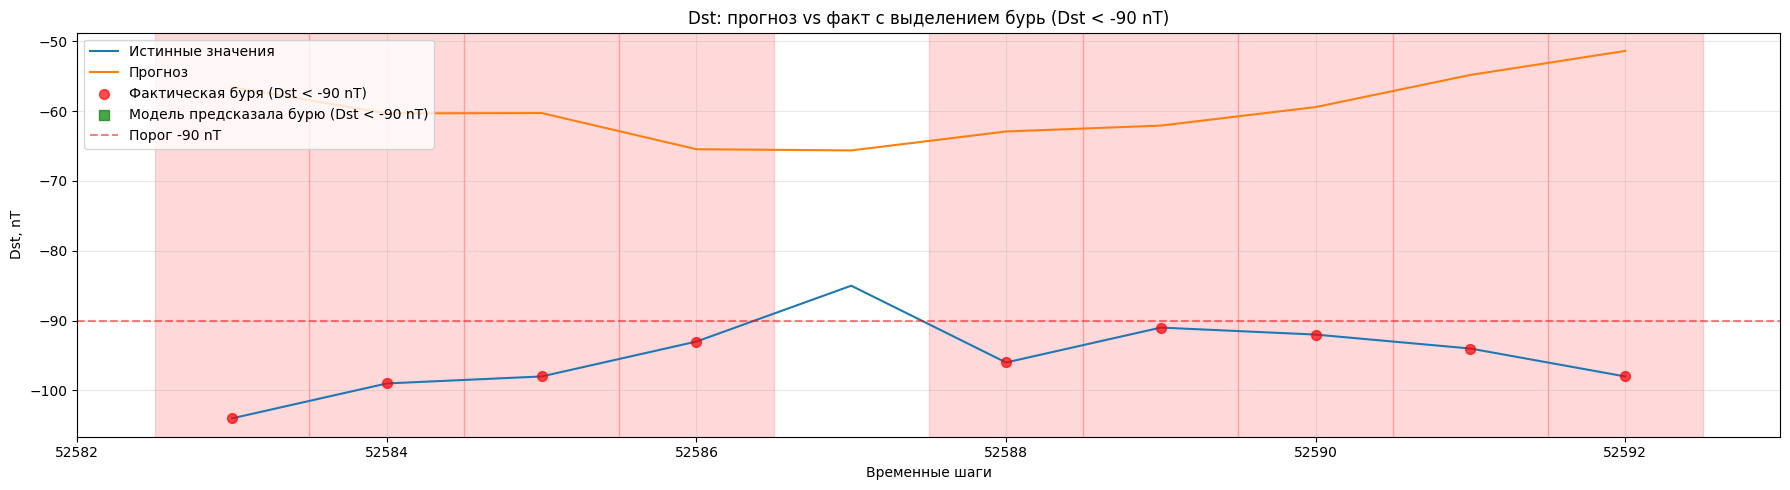

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 9
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


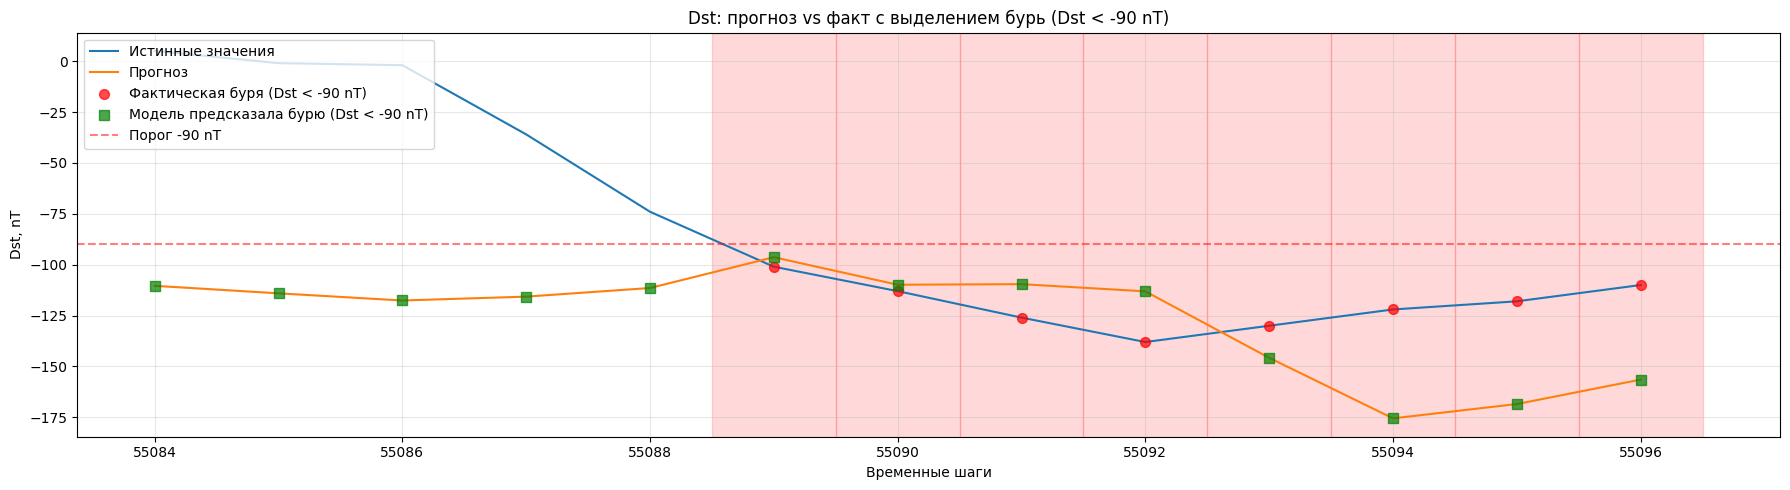

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 13
Precision: 0.615
Recall: 1.000
F1: 0.762


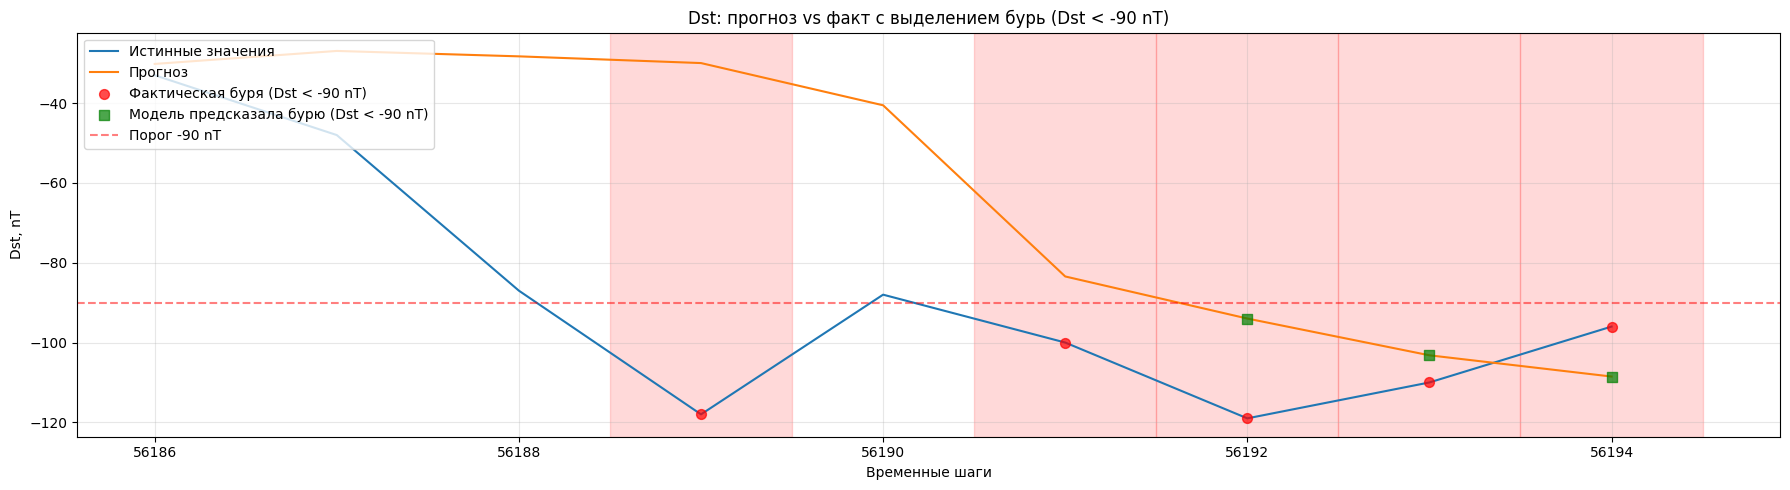

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 5
Всего моментов, когда модель предсказала бурю: 3
Precision: 1.000
Recall: 0.600
F1: 0.750


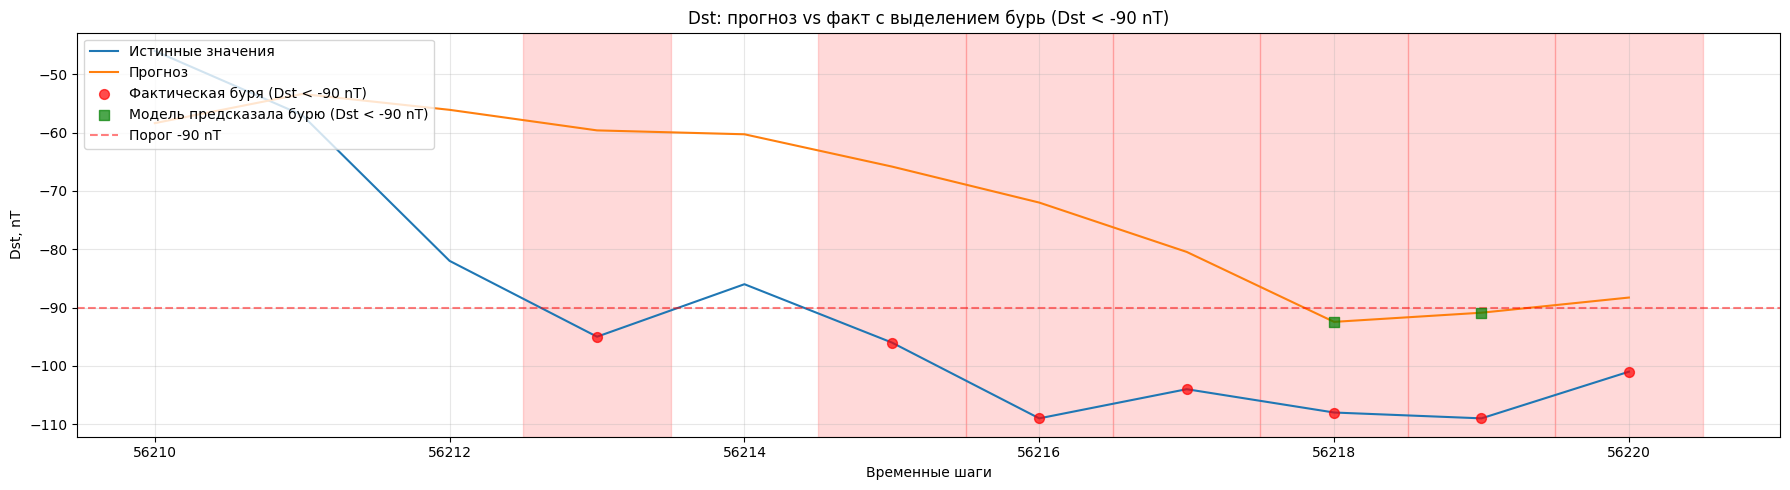

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 7
Всего моментов, когда модель предсказала бурю: 2
Precision: 1.000
Recall: 0.286
F1: 0.444


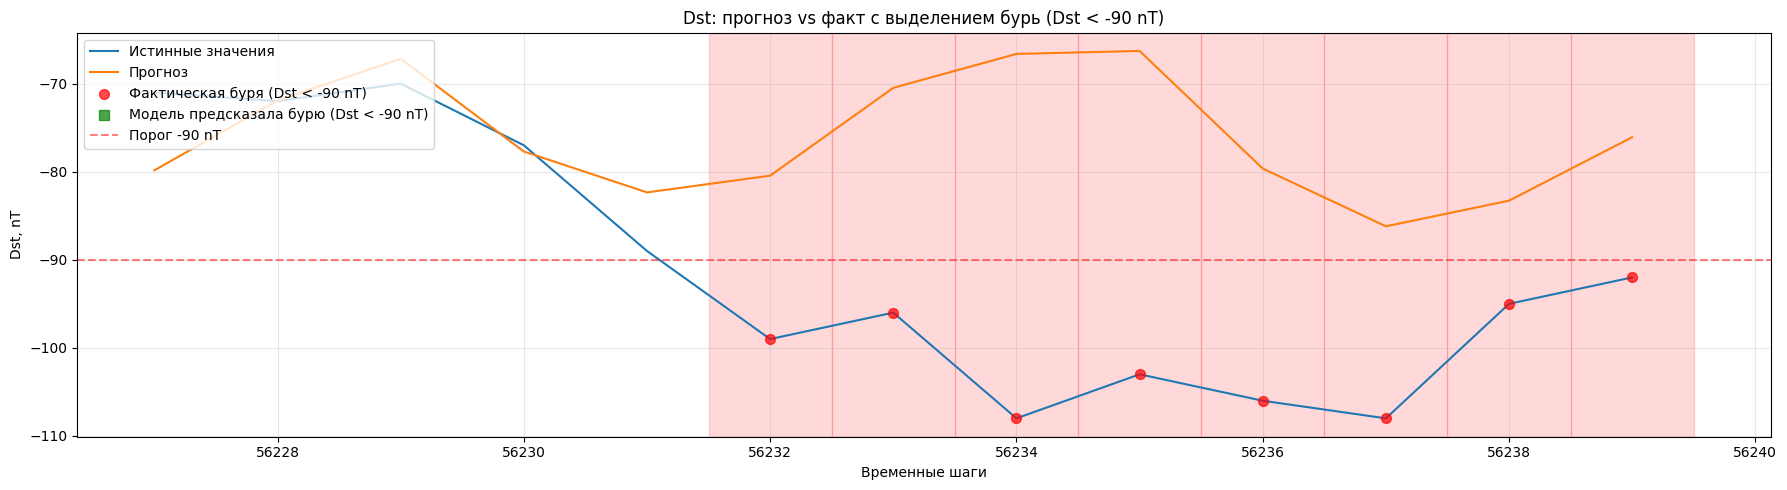

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 8
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


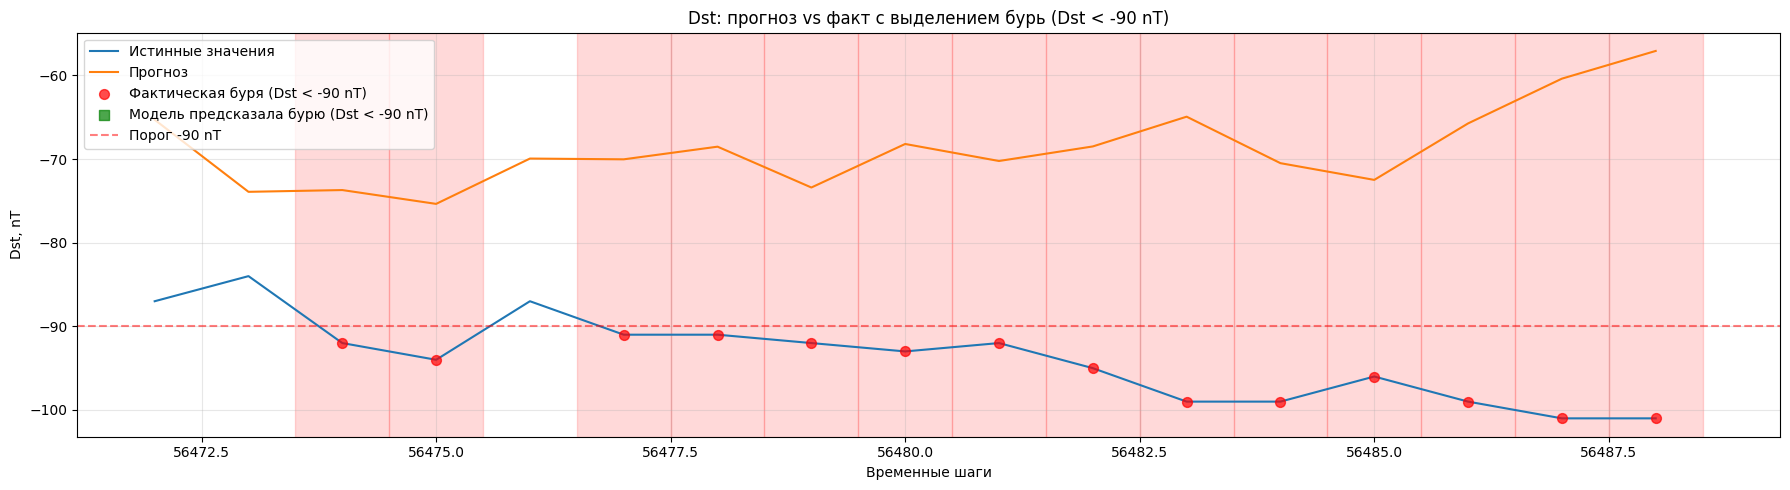

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 14
Всего моментов, когда модель предсказала бурю: 0
Precision: 0.000
Recall: 0.000


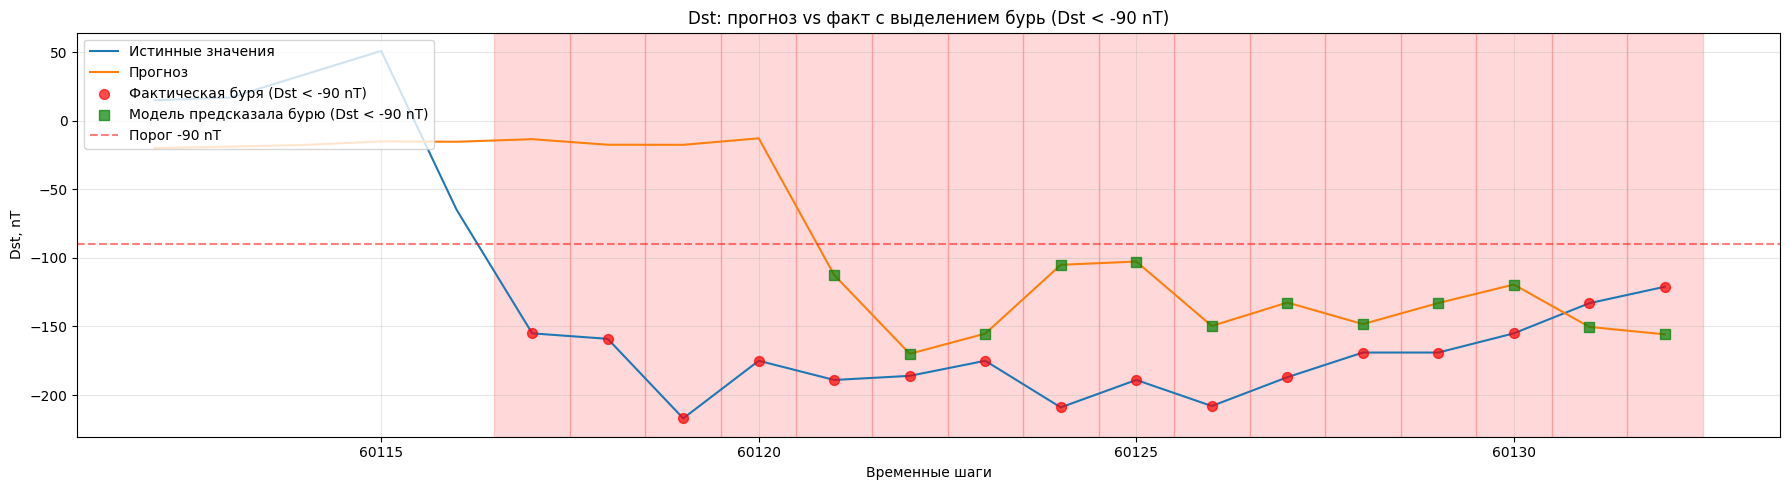

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 16
Всего моментов, когда модель предсказала бурю: 12
Precision: 1.000
Recall: 0.750
F1: 0.857


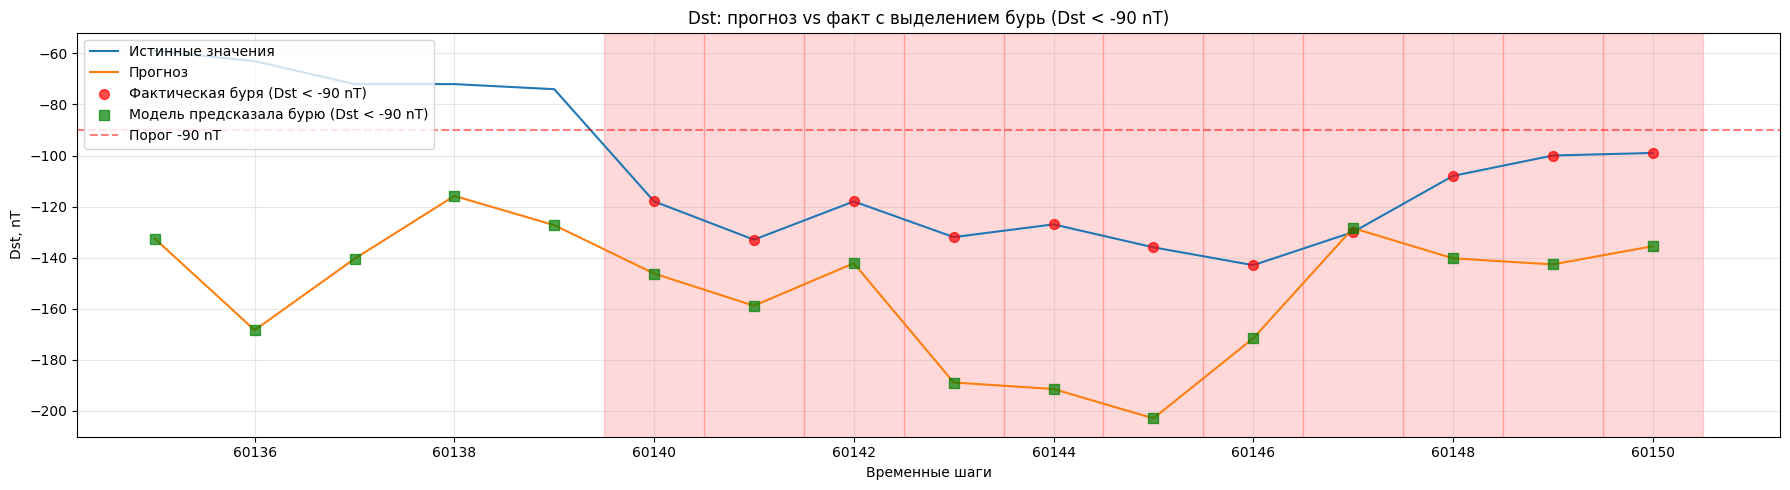

=== Статистика по бурям (Dst < -90 nT) ===
Всего моментов с бурей по факту: 11
Всего моментов, когда модель предсказала бурю: 16
Precision: 0.688
Recall: 1.000
F1: 0.815

Средний F1 по всем бурям: 0.708


In [10]:
result = model(dataset_2019_2025, visualize=True, prefix="2019-2025")

In [11]:
def dst_to_class(dst):
    if isinstance(dst, (int, float)):
        if dst > -50:
            return 0
        elif dst > -100:
            return 1
        elif dst > -200:
            return 2
        else:
            return 3
    
    dst = np.array(dst)
    classes = np.zeros_like(dst, dtype=int)
    classes[dst > -50] = 0
    classes[(dst <= -50) & (dst > -100)] = 1
    classes[(dst <= -100) & (dst > -200)] = 2
    classes[dst <= -200] = 3
    
    return classes

In [12]:
dst_labels = result["dst_labels"]
dst_preds = result["dst_preds"]
ae_labels = result["ae_labels"]
ae_preds = result["ae_preds"]

cr = classification_report(dst_to_class(dst_labels), dst_to_class(dst_preds))
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     59485
           1       0.48      0.46      0.47      1559
           2       0.39      0.46      0.42       224
           3       0.80      0.61      0.69        46

    accuracy                           0.97     61314
   macro avg       0.67      0.63      0.64     61314
weighted avg       0.97      0.97      0.97     61314



In [13]:
# plt.style.use('seaborn-v0_8-whitegrid')
# mpl.rcParams.update({
#     'font.family': 'serif',
#     'font.size': 11,
#     'axes.titlesize': 14,
#     'axes.labelsize': 12,
#     'legend.fontsize': 10,
#     'xtick.labelsize': 10,
#     'ytick.labelsize': 10,
#     'lines.linewidth': 1.5,
#     'figure.dpi': 300,
# })

### Dst-index (индекс кольцевого тока)
Отражает глобальное возмущение геомагнитного поля, вызванное магнитными бурями

In [16]:
import scipy.stats as stats

errors = dst_labels - dst_preds
error_std = np.std(errors)
error_mean = np.mean(errors)
alpha = 0.95
z = stats.norm.ppf((1 + alpha) / 2)

ci_lower = dst_preds + (error_mean - z * error_std)
ci_upper = dst_preds + (error_mean + z * error_std)

AttributeError: 'numpy.ndarray' object has no attribute 'fill_between'

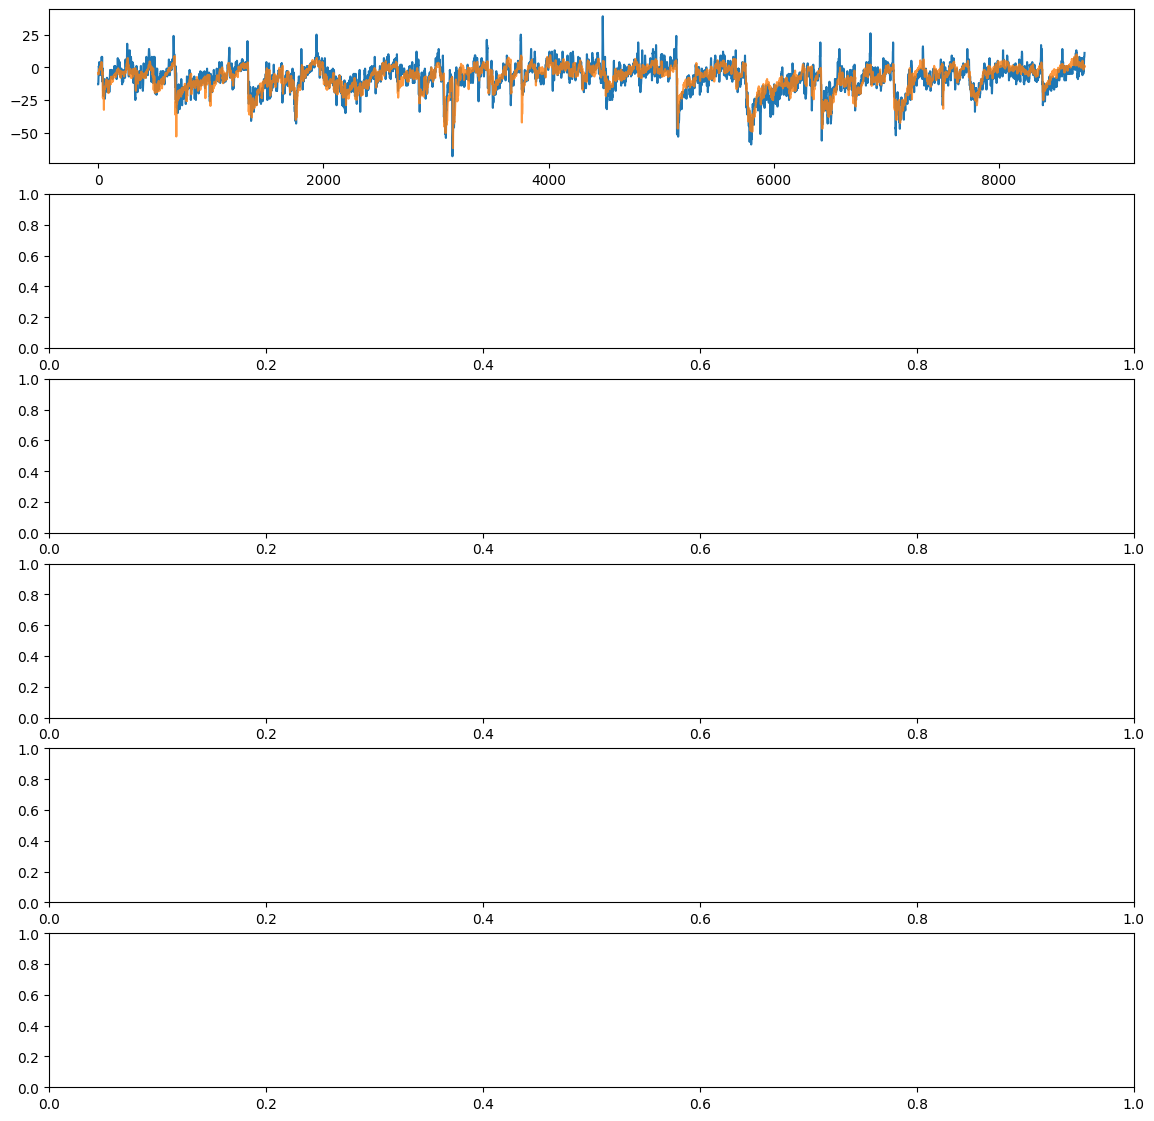

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(14, 14))
axes = axes.flatten()
for idx, x in enumerate([(0, 8760), (8760, 17520), (17520, 26280,), (26280, 35040), (35040, 43800), (43800, 52560)]):
    start, end = x
    axes[idx].plot(dst_labels[start:end], label='Истинные значения')
    axes[idx].plot(dst_preds[start:end], label='Прогноз', alpha=0.8, )
    axes[idx].fill_between(
        range(end - start),
        ci_lower[start:end],
        ci_upper[start:end],
        color='#ff7f0e',
        alpha=0.2,
        label=f'{int(alpha*100)}% доверительный интервал'
    )
  
    axes[idx].grid(alpha=0.5)

fig.suptitle('Dst-index: прогноз за 2019-2025 года', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('Dst, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

### AE-index (индекс авроральной активности)
Отражает уровень магнитных возмущений в полярных областях, связанных с авроральными электроджетами

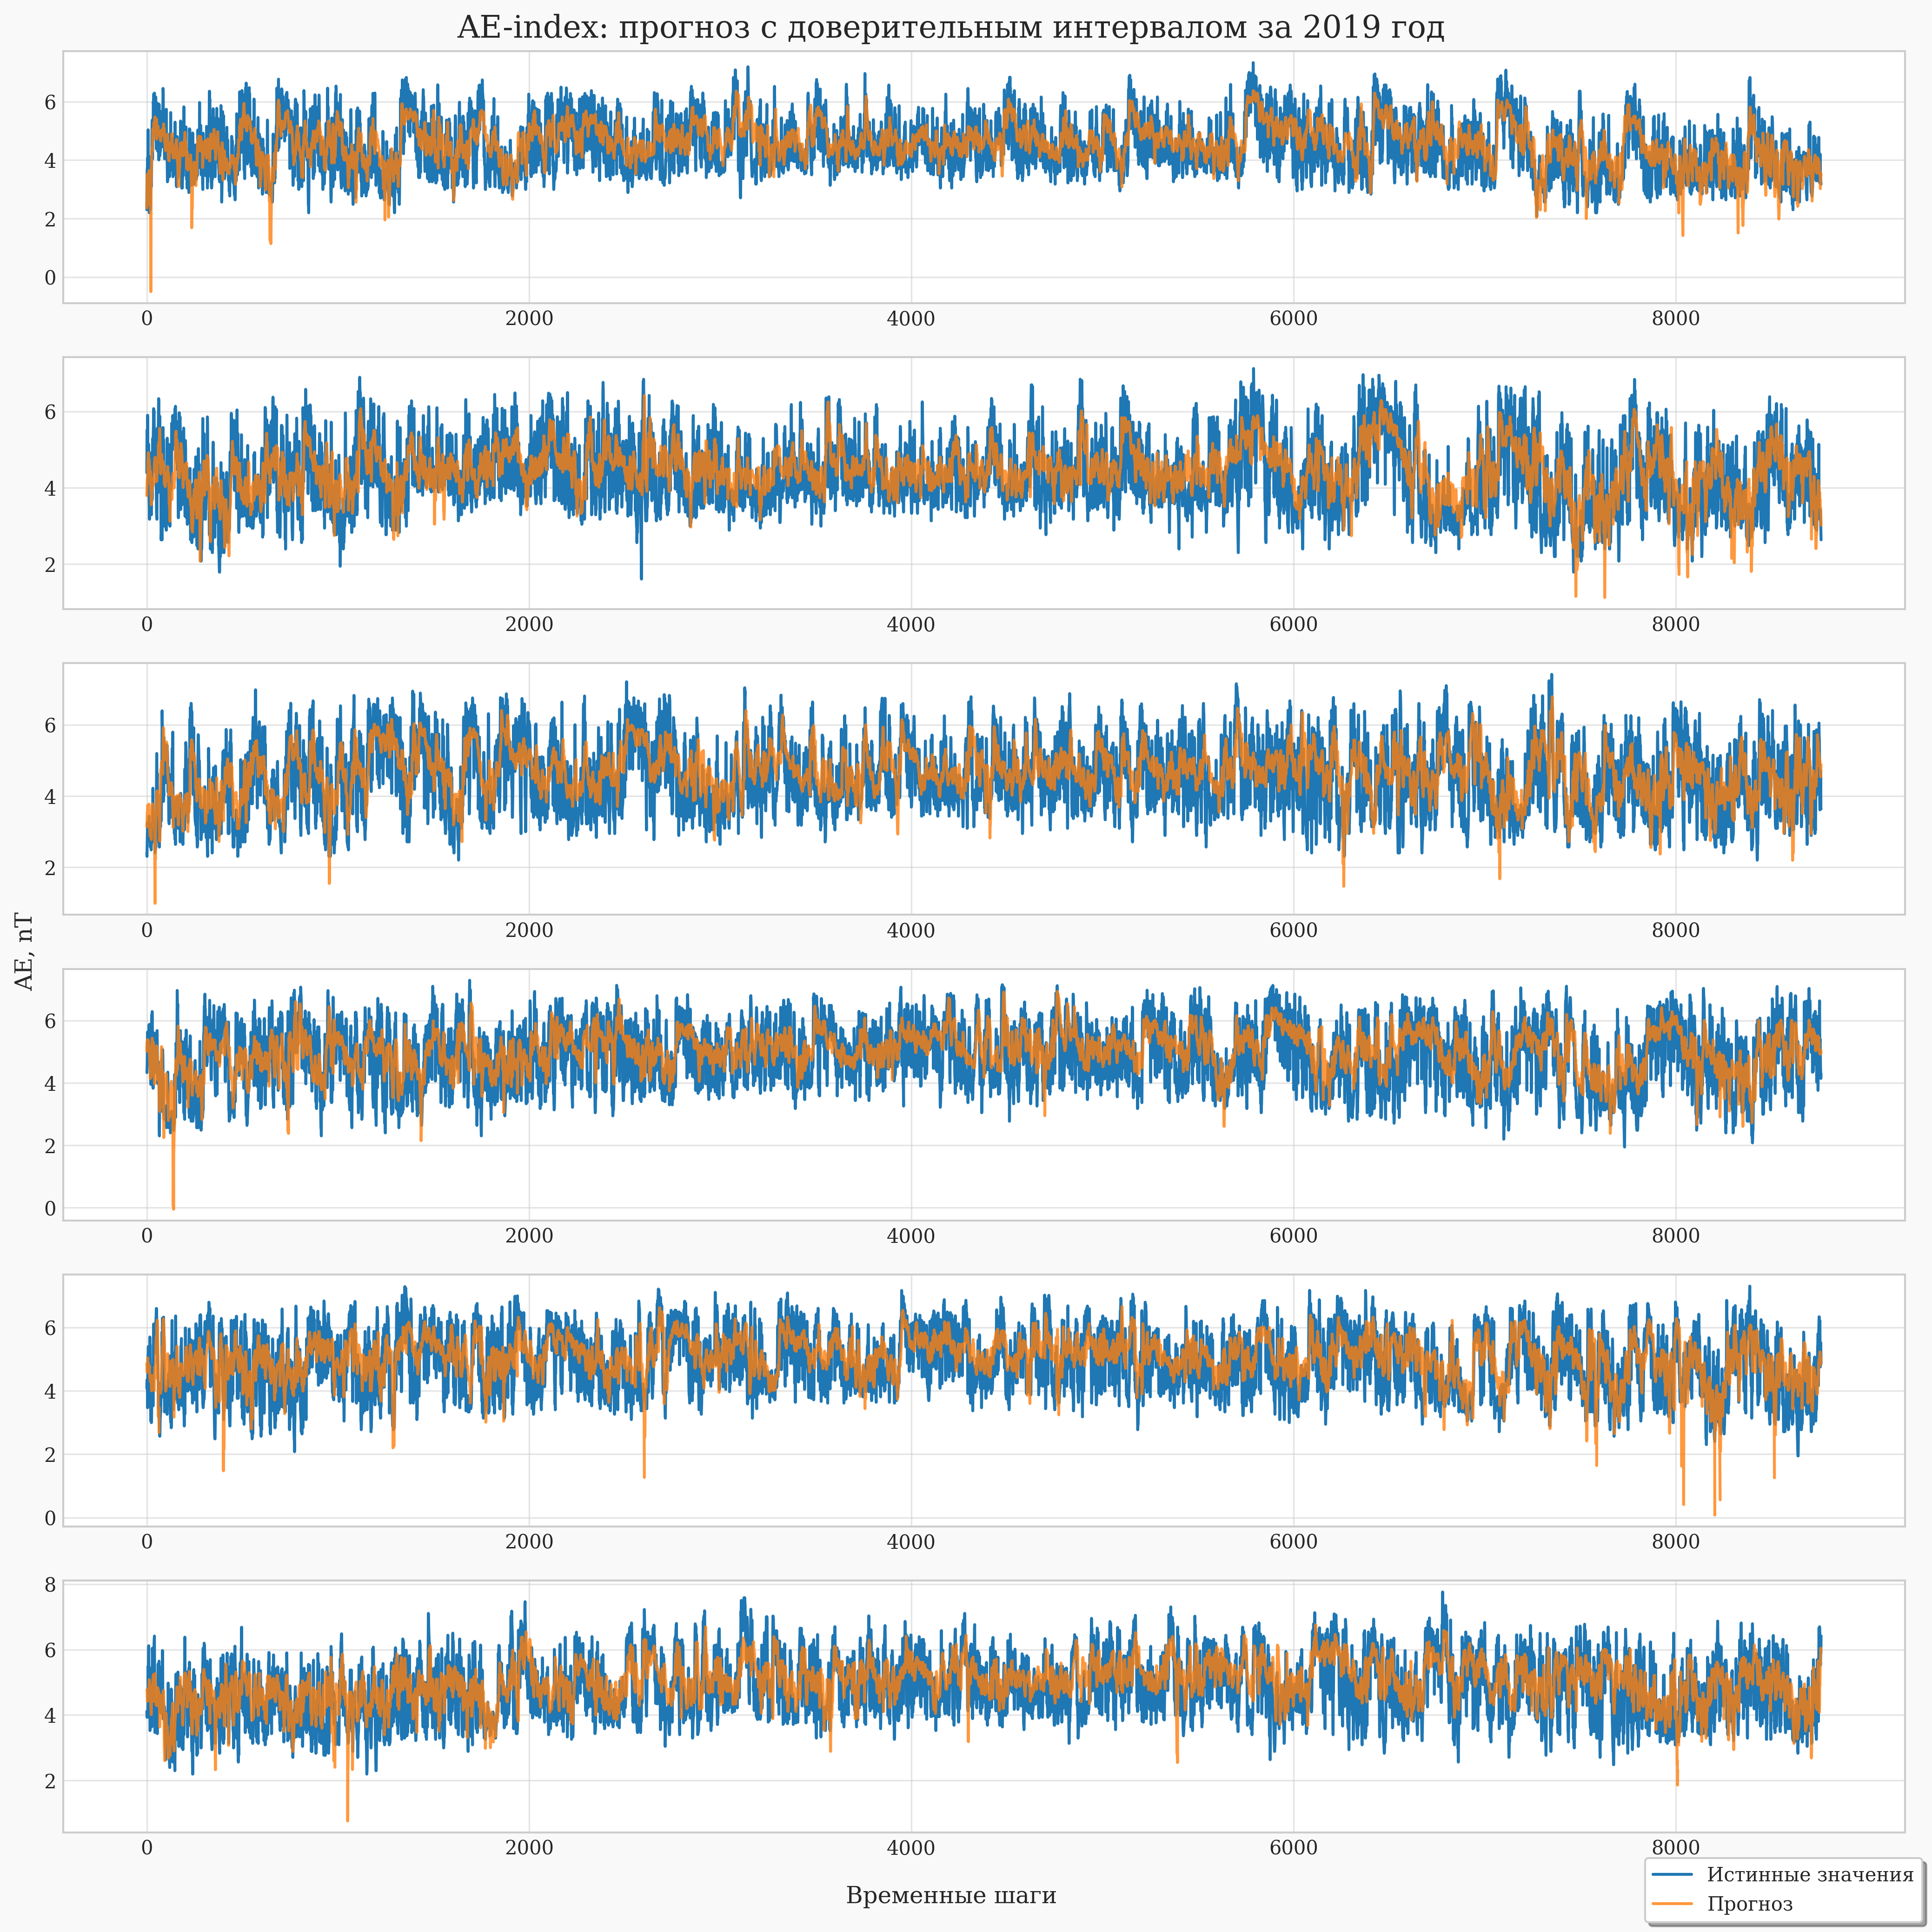

In [39]:
fig, axes = plt.subplots(6, 1, figsize=(14, 14))
axes = axes.flatten()
for idx, x in enumerate([(0, 8760), (8760, 17520), (17520, 26280,), (26280, 35040), (35040, 43800), (43800, 52560)]):
    start, end = x
    axes[idx].plot(np.log1p(ae_labels[start:end]), label='Истинные значения')
    axes[idx].plot(np.log1p(ae_preds[start:end]), label='Прогноз', alpha=0.8, )

    axes[idx].grid(alpha=0.5)

fig.suptitle('AE-index: прогноз с доверительным интервалом за 2019 год', fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, frameon=True, fancybox=True, shadow=True)
fig.supxlabel('Временные шаги', fontsize=12)
fig.supylabel('AE, nT', fontsize=12)
fig.patch.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [3]:
(dst_preds, ae_preds, dst_attention, ae_attention), last_batch = model.predict_next("omni2_2026.dat")

Последний найденный индекс без последующих пропусков в файле: 3287, 136-й день с начала года


Если проаналиировать файл за 2026 год, видно, что с этого индекса обрывается 3 колонки - `AL AU AE`